# Analysis of memory-pool simulations

## Set up

In [1]:
suppressMessages({
    require(RColorBrewer, quietly=TRUE)
    require(data.table, quietly=TRUE)
    require(ggplot2, quietly=TRUE)
    require(ggraph, quietly=TRUE)
    require(igraph, quietly=TRUE)
    require(magrittr, quietly=TRUE)
    require(tidygraph, quietly=TRUE)
})

## Adversarial nodes, with 2 ms delay for front-running and at 6 TPS

### Read data

In [2]:
adversariesLeios <- fread("adversaries.tsv.gz", stringsAsFactors=TRUE)
adversariesLeios[, `Honest txs`:=`RB honest txs`+`EB honest txs`]
adversariesLeios[, `Adversarial txs`:=`RB adversarial txs`+`EB adversarial txs`]
adversariesLeios[, `Txs`:=`Honest txs`+`Adversarial txs`]

In [3]:
adversariesPraos <- fread("../experiment-praos/adversaries.tsv.gz", stringsAsFactors=TRUE)
adversariesPraos[, `Honest txs`:=`RB honest txs`+`EB honest txs`]
adversariesPraos[, `Adversarial txs`:=`RB adversarial txs`+`EB adversarial txs`]
adversariesPraos[, `Txs`:=`Honest txs`+`Adversarial txs`]

In [4]:
adversariesPraos0 <- fread("../experiment-praos-0ms/adversaries.tsv.gz", stringsAsFactors=TRUE)
adversariesPraos0[, `Honest txs`:=`RB honest txs`+`EB honest txs`]
adversariesPraos0[, `Adversarial txs`:=`RB adversarial txs`+`EB adversarial txs`]
adversariesPraos0[, `Txs`:=`Honest txs`+`Adversarial txs`]

In [5]:
adversaries <- rbind(
    cbind(`Protocol`=factor("Praos", levels=c("Praos", "Leios")), `Adversarial delay`=factor("2 ms", levels=c("-2 ms", "2 ms")), adversariesPraos),
    cbind(`Protocol`=factor("Praos", levels=c("Praos", "Leios")), `Adversarial delay`=factor("-2 ms", levels=c("-2 ms", "2 ms")), adversariesPraos0),
    cbind(`Protocol`=factor("Leios", levels=c("Praos", "Leios")), `Adversarial delay`=factor("2 ms", levels=c("-2 ms", "2 ms")), adversariesLeios)
)
adversaries %>% summary

  Protocol    Adversarial delay Adversarial nodes     RB ID      RB honest txs 
 Praos:3632   -2 ms:1819        Min.   :  0.0     B0     : 303   Min.   : 0.0  
 Leios:1814   2 ms :3627        1st Qu.:125.0     B1     : 303   1st Qu.:23.0  
                                Median :250.0     B2     : 303   Median :53.0  
                                Mean   :251.4     B3     : 303   Mean   :40.7  
                                3rd Qu.:375.0     B4     : 303   3rd Qu.:60.0  
                                Max.   :500.0     B5     : 303   Max.   :60.0  
                                                  (Other):3628                 
 RB adversarial txs     EB ID      EB honest txs     EB adversarial txs
 Min.   : 0.000            :1075   Min.   :   0.00   Min.   : 0.00000  
 1st Qu.: 0.000     EB2    :  52   1st Qu.:   0.00   1st Qu.: 0.00000  
 Median : 0.000     EB5    :  51   Median :   0.00   Median : 0.00000  
 Mean   : 3.603     EB9    :  50   Mean   :  23.07   Mean   : 0.09218  


### Trends

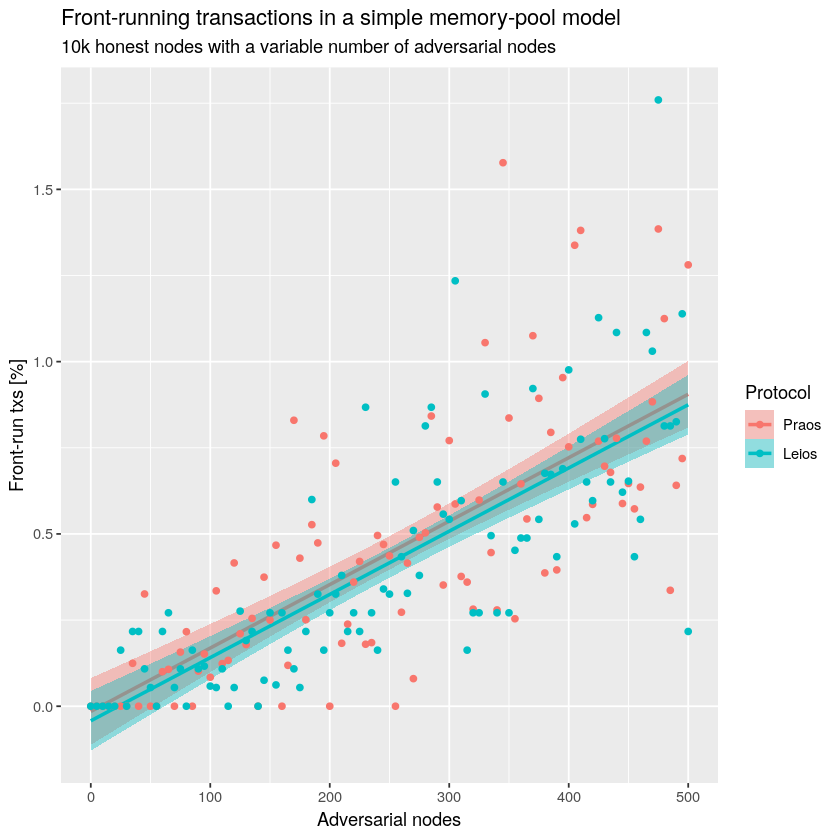

In [6]:
ggplot(
    adversaries[
        `Adversarial delay`=="2 ms",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Protocol`, `Adversarial nodes`)
    ], 
    aes(x=`Adversarial nodes`, y=`Front-run txs [%]`, color=`Protocol`, fill=`Protocol`)
) +
    geom_smooth(formula=y~x, method="lm") +
    geom_point() +
    ggtitle(
        "Front-running transactions in a simple memory-pool model",
        "10k honest nodes with a variable number of adversarial nodes"
    )

In [7]:
ggsave("adversarial-scatter-2ms-delay.png", units="in", dpi=150, width=8, height=6)

In [8]:
ggsave("adversarial-scatter-2ms-delay.svg", units="in", dpi=150, width=8, height=6)

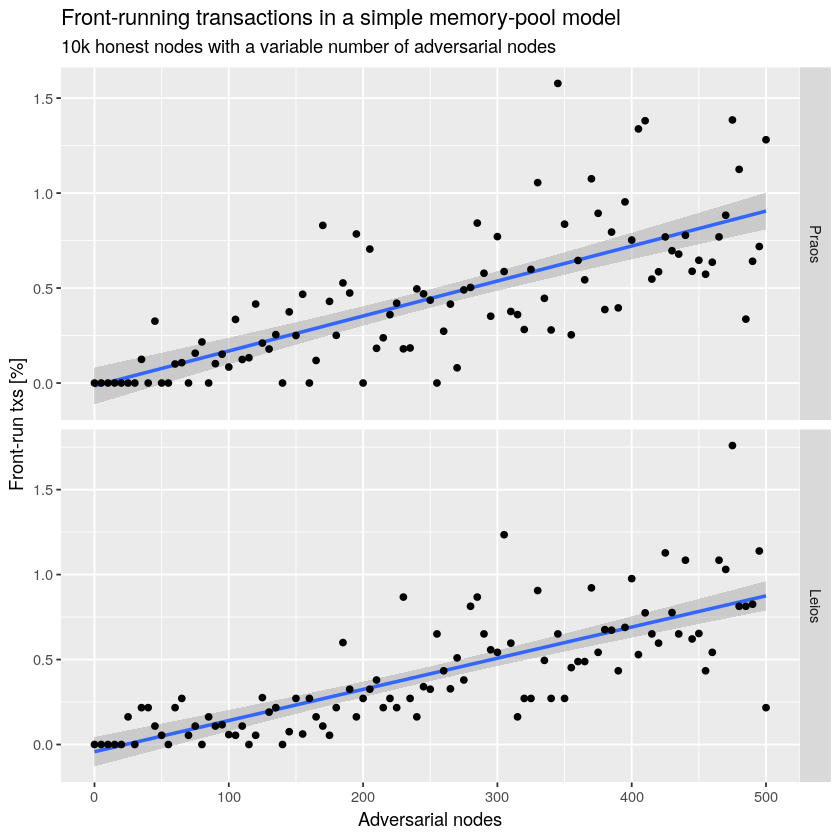

In [9]:
ggplot(
    adversaries[
        `Adversarial delay`=="2 ms",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Protocol`, `Adversarial nodes`)
    ], 
    aes(x=`Adversarial nodes`, y=`Front-run txs [%]`)
) +
    geom_smooth(formula=y~x, method="lm") +
    geom_point() +
    facet_grid(`Protocol` ~ ., scales="free_y") +
    ggtitle(
        "Front-running transactions in a simple memory-pool model",
        "10k honest nodes with a variable number of adversarial nodes"
    )

In [10]:
ggsave("adversarial-scatter-2ms-delay-split.png", units="in", dpi=150, width=8, height=6)

In [11]:
ggsave("adversarial-scatter-2ms-delay-split.svg", units="in", dpi=150, width=8, height=6)

### Regression model

### Leios

In [12]:
lm(
    `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`,
    data=adversaries[
        `Protocol` == "Leios",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Fraction adversarial nodes [%]`=100*`Adversarial nodes`/(10000+`Adversarial nodes`))
    ]
) %>% summary


Call:
lm(formula = `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`, 
    data = adversaries[Protocol == "Leios", .(`Front-run txs [%]` = 100 * 
        sum(`Adversarial txs`)/sum(Txs)), .(`Fraction adversarial nodes [%]` = 100 * 
        `Adversarial nodes`/(10000 + `Adversarial nodes`))])

Residuals:
     Min       1Q   Median       3Q      Max 
-0.65021 -0.12622 -0.01385  0.05827  0.93615 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -0.04937    0.04409   -1.12    0.266    
`Fraction adversarial nodes [%]`  0.19246    0.01581   12.18   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2205 on 99 degrees of freedom
Multiple R-squared:  0.5996,	Adjusted R-squared:  0.5955 
F-statistic: 148.2 on 1 and 99 DF,  p-value: < 2.2e-16


### Praos

In [13]:
lm(
    `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`,
    data=adversaries[
        `Protocol` == "Praos",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Fraction adversarial nodes [%]`=100*`Adversarial nodes`/(10000+`Adversarial nodes`))
    ]
) %>% summary


Call:
lm(formula = `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`, 
    data = adversaries[Protocol == "Praos", .(`Front-run txs [%]` = 100 * 
        sum(`Adversarial txs`)/sum(Txs)), .(`Fraction adversarial nodes [%]` = 100 * 
        `Adversarial nodes`/(10000 + `Adversarial nodes`))])

Residuals:
    Min      1Q  Median      3Q     Max 
-5.9955 -1.1535 -0.2954  1.3804  7.4081 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        1.0114     0.4033   2.508   0.0138 *  
`Fraction adversarial nodes [%]`   3.8211     0.1446  26.428   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.017 on 99 degrees of freedom
Multiple R-squared:  0.8759,	Adjusted R-squared:  0.8746 
F-statistic: 698.4 on 1 and 99 DF,  p-value: < 2.2e-16


## Effect of adversarial delay

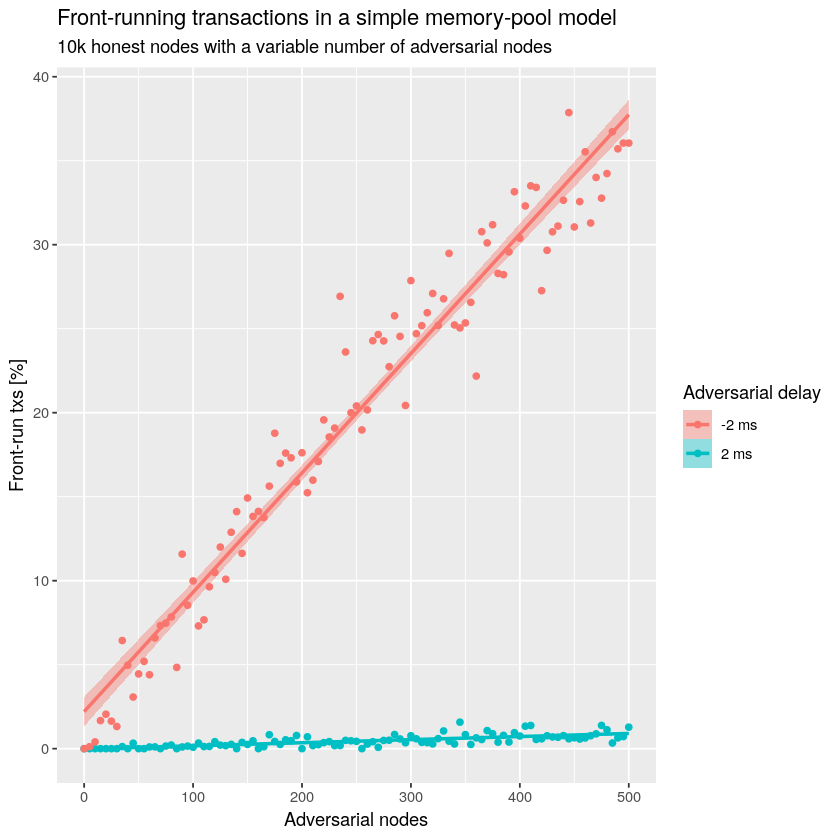

In [14]:
ggplot(
    adversaries[
        `Protocol`=="Praos",
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Adversarial delay`, `Adversarial nodes`)
    ], 
    aes(x=`Adversarial nodes`, y=`Front-run txs [%]`, color=`Adversarial delay`, fill=`Adversarial delay`)
) +
    geom_smooth(formula=y~x, method="lm") +
    geom_point() +
    ggtitle(
        "Front-running transactions in a simple memory-pool model",
        "10k honest nodes with a variable number of adversarial nodes"
    )

In [15]:
ggsave("adversarial-scatter-neg2ms-delay.png", units="in", dpi=150, width=8, height=6)

In [16]:
ggsave("adversarial-scatter-neg2ms-delay-split.svg", units="in", dpi=150, width=8, height=6)